In [1]:
import os
import numpy as np
import efficientnet.tfkeras
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model, model_from_json
from tensorflow.keras import optimizers
import tensorflow as tf

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"]= "1"

physical_devices = tf.config.list_physical_devices('GPU')
print('Num GPUs Available:', len(tf.config.experimental.list_physical_devices('GPU')))
print(tf.test.is_gpu_available(cuda_only=False, min_cuda_compute_capability=None))

Num GPUs Available: 1
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
True


## Load EffNet : 15AB

In [3]:
model_dir = '/media/tohn/HDD2/Model_unlearn/EffNetB5Model/MLunlearn_USAI/R2_unbalanced/unfreezeBlock5a_se_excite/exp_unfreezeB4-B7/models/modelEffNetB5_MLunlearn_USAI_unfreezeBlock5a_se_excite_exp_unfreezeB4-B7-R2_unbalanced.h5'
model = load_model(model_dir)
height = width = model.input_shape[1]
print(height, width)

456 456


In [4]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
new_input (InputLayer)       [(None, 456, 456, 3)]     0         
_________________________________________________________________
efficientnet-b5 (Functional) (None, None, None, 2048)  28513520  
_________________________________________________________________
global_average_pooling2d (Gl (None, 2048)              0         
_________________________________________________________________
dropout (Dropout)            (None, 2048)              0         
_________________________________________________________________
prediction_layer (Dense)     (None, 15)                30735     
Total params: 28,544,255
Trainable params: 26,109,423
Non-trainable params: 2,434,832
_________________________________________________________________


In [5]:
# validation
import pandas as pd
base_dir = '/media/tohn/SSD/Images/Image1'
dataframe = pd.read_csv( '/media/tohn/HDD/VISION_dataset/Valdf_fold3_v2.csv')#แก้
validation_dir = os.path.join(base_dir, 'test')

#Train
train_df = pd.read_csv( '/media/tohn/HDD/VISION_dataset/Traindf_fold4_8_v2.csv')#แก้
base_dir = '/media/tohn/SSD/Images/Image1'
os.chdir(base_dir)
train_dir = os.path.join(base_dir, 'train')

In [6]:
len(set(dataframe['Sub_class_New']))

15

In [7]:
import pandas as pd

## Field Test set
dataframe = pd.read_csv ('/home/yupaporn/CSV_file/UICCA_DiagRadioExp_AzureDb51Case813Image.csv')
dataframe = dataframe[dataframe['Sub_Class_15AB']!= 'None']
dataframe = dataframe.reset_index()
print(dataframe.shape)
dataframe.head(5)

(807, 26)


,index,Unnamed: 0,Case,FileName,Views,Label,Width,Height,X1,Y1,...,date,originalImage,Path Full,Class,Sub_class_name,Sub_class,Path Crop,Path Crop_I7,Sub_Class_15AB,Views_
0,0,0,12215,12215_9.jpg,P42,Normal,800,600,219.60,113.40,...,20/10/2021,1.2.392.200039.110.1.109018960.10.20211020.150...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-B
1,1,1,12215,12215_8.jpg,P41,Normal,800,600,227.00,120.20,...,20/10/2021,1.2.392.200039.110.1.109018960.10.20211020.150...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-B
2,2,2,12215,12215_7.jpg,P52,Normal,800,600,290.00,129.30,...,20/10/2021,1.2.392.200039.110.1.109018960.10.20211020.150...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-C
3,3,3,12215,12215_6.jpg,P52,Normal,800,600,289.90,138.40,...,20/10/2021,1.2.392.200039.110.1.109018960.10.20211020.150...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-C
4,4,4,12215,12215_5.jpg,P61,Normal,800,600,236.70,132.70,...,20/10/2021,1.2.392.200039.110.1.109018960.10.20211020.150...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-C


> ### Plot image

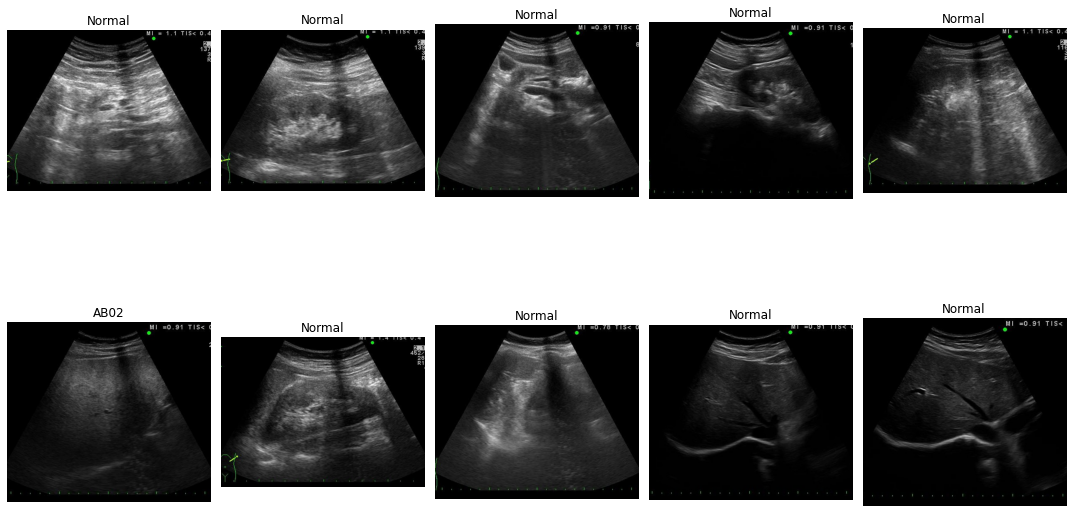

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# สุ่ม 10 ภาพแบบไม่ซ้ำ
sample_df = dataframe.sample(n=10, replace=False)

# สร้างแผนภาพ
plt.figure(figsize=(15, 10))

for i, (img_path, label) in enumerate(zip(sample_df["Path Crop_I7"], sample_df["Sub_Class_15AB"])):
    try:
        image = Image.open(img_path)
        plt.subplot(2, 5, i+1)
        plt.imshow(image)
        plt.axis('off')
        plt.title(str(label))
    except Exception as e:
        print(f"Error loading image {img_path}: {e}")

plt.tight_layout()
plt.show()

-------------------------------------------------------------

In [8]:
batch_size = 16

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=30,
      width_shift_range=0.2,
      height_shift_range=0.2,
      brightness_range=[0.5,1.5],
      shear_range=0.4,
      zoom_range=0.2,
      horizontal_flip=False,
      fill_mode='nearest')

train_generator = train_datagen.flow_from_dataframe(
        dataframe = dataframe,
        directory = train_dir,
        x_col = 'Path Crop_I7',
        y_col = 'Sub_Class_15AB',
        target_size = (height, width),
        batch_size=batch_size,
        color_mode= 'rgb',
        class_mode='categorical')

#label
labels = (train_generator.class_indices)
labels = dict((v,k.replace("C","")) for k,v in labels.items())
print(labels)

Found 807 validated image filenames belonging to 10 classes.
{0: 'AB01', 1: 'AB02', 2: 'AB03', 3: 'AB05', 4: 'AB06', 5: 'AB081', 6: 'AB09', 7: 'AB10', 8: 'AB11', 9: 'Normal'}


In [10]:
## Set Label (same tain set)
labels = {0: 'AB01', 1: 'AB02', 2: 'AB03', 3: 'AB04', 4: 'AB05', 5: 'AB06', 6: 'AB07', 7: 'AB081', 8: 'AB082', 
              9: 'AB083', 10: 'AB09', 11: 'AB10', 12: 'AB11', 13: 'AB12', 14: 'Normal'}
print(labels)

{0: 'AB01', 1: 'AB02', 2: 'AB03', 3: 'AB04', 4: 'AB05', 5: 'AB06', 6: 'AB07', 7: 'AB081', 8: 'AB082', 9: 'AB083', 10: 'AB09', 11: 'AB10', 12: 'AB11', 13: 'AB12', 14: 'Normal'}


# Prediction

In [11]:
from tensorflow.keras.preprocessing import image
def predict_image(img_path):
    # Read the image and resize it
    img = image.load_img(img_path, target_size=(height, width))
    # Convert it to a Numpy array with target shape.
    x = image.img_to_array(img)
    # Reshape
    x = x.reshape((1,) + x.shape)
    x /= 255.
    result = model.predict([x])
    
    return result[0]

#Predict
pred_list = list()
prob_list = list()
img_path=dataframe['Path Crop_I7'].tolist()
for i in range(0,len(img_path)):
    print(i+1)
    predict = predict_image(img_path[i])
    result = np.argmax(predict)
    pred_list.append(labels[result])
    prob_list.append(predict[result])

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [12]:
print(len(pred_list))
print(len(prob_list))

dataframe['category'] = pred_list
dataframe['Prob'] = prob_list
print(dataframe.shape)
dataframe.head()

807
807
(807, 28)


,index,Unnamed: 0,Case,FileName,Views,Label,Width,Height,X1,Y1,...,Path Full,Class,Sub_class_name,Sub_class,Path Crop,Path Crop_I7,Sub_Class_15AB,Views_,category,Prob
0,0,0,12215,12215_9.jpg,P42,Normal,800,600,219.60,113.40,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-B,Normal,0.999901
1,1,1,12215,12215_8.jpg,P41,Normal,800,600,227.00,120.20,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-B,Normal,0.999311
2,2,2,12215,12215_7.jpg,P52,Normal,800,600,290.00,129.30,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-C,AB12,0.999697
3,3,3,12215,12215_6.jpg,P52,Normal,800,600,289.90,138.40,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-C,AB12,0.949820
4,4,4,12215,12215_5.jpg,P61,Normal,800,600,236.70,132.70,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-C,AB11,0.993141


In [13]:
dataframe.to_csv("/home/kannika/code/Result_EffNetB5_Fine-Tune-Machine-Unlearning-unfreezeB4-B7_R2_FieldTestset.csv")

------------------

# Evaluation

In [14]:
#เช็คคลาสใน Predicted
pred_class = set(dataframe['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(dataframe['Sub_Class_15AB'])
print('Actual : ',len(classe))
print(classe)

Predicted :  10
{'AB11', 'AB09', 'AB082', 'AB02', 'AB04', 'AB12', 'Normal', 'AB05', 'AB03', 'AB06'}
Actual :  10
{'AB01', 'AB11', 'AB09', 'AB02', 'AB10', 'Normal', 'AB05', 'AB03', 'AB06', 'AB081'}


In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix

act = dataframe['Sub_Class_15AB'].array
pred = dataframe['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 84.88228004956629%
              precision    recall  f1-score   support

        AB01       0.00      0.00      0.00        20
        AB02       0.00      0.00      0.00         8
        AB03       0.67      0.75      0.71         8
        AB04       0.00      0.00      0.00         0
        AB05       0.00      0.00      0.00         1
        AB06       0.00      0.00      0.00         3
       AB081       0.00      0.00      0.00         2
       AB082       0.00      0.00      0.00         0
        AB09       1.00      0.25      0.40         4
        AB10       0.00      0.00      0.00         6
        AB11       0.14      0.80      0.23        10
        AB12       0.00      0.00      0.00         0
      Normal       0.95      0.90      0.92       745

    accuracy                           0.85       807
   macro avg       0.21      0.21      0.17       807
weighted avg       0.89      0.85      0.87       807



/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kan

Text(0.5, 21.5, 'Predicted label')

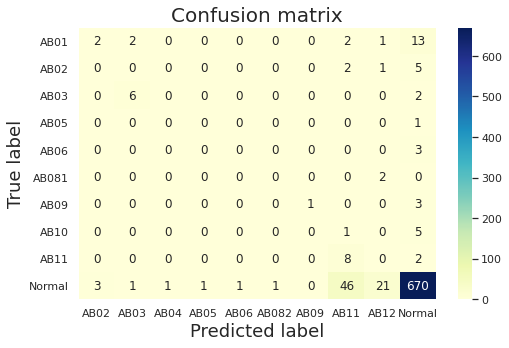

In [16]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

In [17]:
# act= p1['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
act= dataframe['Sub_Class_15AB'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
pred = dataframe['category'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 86.49318463444858%
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       745
           1       0.27      0.45      0.34        62

    accuracy                           0.86       807
   macro avg       0.61      0.68      0.63       807
weighted avg       0.90      0.86      0.88       807



670 75 34 28


Text(48.5, 0.5, 'True label')

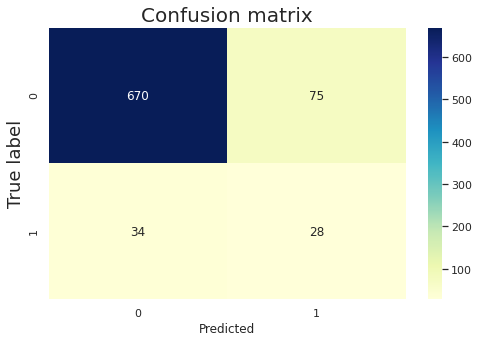

In [18]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
#plot Confusion matrix
import seaborn as sns

#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

cm = confusion_matrix(act, pred)
TN, FP, FN, TP = confusion_matrix(act, pred).ravel()
print(TN, FP, FN, TP)

sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)

In [19]:
Sub_class_New = list(set(dataframe['Sub_Class_15AB']))

for i in range(len(Sub_class_New)):
    df = dataframe[dataframe['Sub_Class_15AB'] == Sub_class_New[i]]
    
    act = df['Sub_Class_15AB'].array
    pred = df['category'].array

    cmat = confusion_matrix(act, pred)
    print('######', Sub_class_New[i])
#     print(cmat)
#     print(classification_report(act, pred))
    
    print('classifier accuracy = {}% \n'.format((np.trace(cmat))/(np.sum(cmat))))

###### AB01
classifier accuracy = 0.0% 

###### AB11
classifier accuracy = 0.8% 

###### AB09
classifier accuracy = 0.25% 

###### AB02
classifier accuracy = 0.0% 

###### AB10
classifier accuracy = 0.0% 

###### Normal
classifier accuracy = 0.8993288590604027% 

###### AB05
classifier accuracy = 0.0% 

###### AB03
classifier accuracy = 0.75% 

###### AB06
classifier accuracy = 0.0% 

###### AB081
classifier accuracy = 0.0% 



-----------

-------

# Exclude Normal classes

In [20]:
dataframe0_ = dataframe[(dataframe["Sub_Class_15AB"]!="Normal") & (dataframe['category']!="Normal")].reset_index(drop=True)
print(dataframe0_.shape)
dataframe0_.head()

(28, 28)


,index,Unnamed: 0,Case,FileName,Views,Label,Width,Height,X1,Y1,...,Path Full,Class,Sub_class_name,Sub_class,Path Crop,Path Crop_I7,Sub_Class_15AB,Views_,category,Prob
0,51,51,12273,12273_6.jpg,P51,Livermass,800,600,217.29,91.17,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,AB081,FP-C,AB12,0.601180
1,52,52,12273,12273_5.jpg,P41,Livermass,800,600,190.89,123.90,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,AB081,FP-B,AB12,0.699598
2,197,197,6668,06668_11.jpg,P72,RenalCyst,800,600,200.00,189.47,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/06...,Abnormal,"['ModerateFattyLiver', 'RenalCyst']","['AB02', 'AB11']",/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,AB11,FP-D,AB11,0.999997
3,198,198,6668,06668_12.jpg,P72,RenalCyst,800,600,336.14,223.86,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/06...,Abnormal,"['ModerateFattyLiver', 'RenalCyst']","['AB02', 'AB11']",/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,AB11,FP-D,AB11,0.999998
4,199,199,6668,06668_13.jpg,P72,RenalCyst,800,600,386.67,229.47,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/06...,Abnormal,"['ModerateFattyLiver', 'RenalCyst']","['AB02', 'AB11']",/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,AB11,FP-D,AB11,0.998801


In [21]:
data_train = dataframe0_
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_Class_15AB'])
print('Actual : ',len(classe))
print(classe)

Predicted :  5
{'AB11', 'AB09', 'AB02', 'AB12', 'AB03'}
Actual :  7
{'AB11', 'AB01', 'AB09', 'AB02', 'AB10', 'AB03', 'AB081'}


In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix

act = data_train['Sub_Class_15AB'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 53.57142857142857%
              precision    recall  f1-score   support

        AB01       0.00      0.00      0.00         7
        AB02       0.00      0.00      0.00         3
        AB03       0.75      1.00      0.86         6
       AB081       0.00      0.00      0.00         2
        AB09       1.00      1.00      1.00         1
        AB10       0.00      0.00      0.00         1
        AB11       0.62      1.00      0.76         8
        AB12       0.00      0.00      0.00         0

    accuracy                           0.54        28
   macro avg       0.30      0.38      0.33        28
weighted avg       0.37      0.54      0.44        28



/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kan

Text(0.5, 21.5, 'Predicted label')

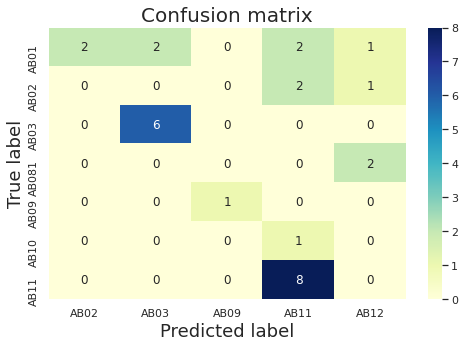

In [23]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
#plot Confusion matrix
import seaborn as sns

#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])
cm = confusion_matrix(act, pred)

sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)